#  ROCO v2 Dataset Exploration

## Project Overview

This notebook presents the **Exploratory Data Analysis (EDA)** of the **ROCO v2 (Radiology Objects in Context Version 2)** dataset, a large-scale biomedical vision-language dataset designed for medical image captioning and multimodal learning.

The primary objective of this notebook is to thoroughly understand the dataset before performing preprocessing and model development. A comprehensive exploration helps identify data quality issues, understand image and caption distributions, and establish a reliable foundation for subsequent deep learning experiments.

---

## Dataset Information

| Attribute | Description |
|-----------|-------------|
| **Dataset Name** | ROCO v2 (Radiology Objects in Context Version 2) |
| **Domain** | Biomedical Image Captioning |
| **Dataset Source** | PubMed Central Open Access (PMC-OA) Articles |
| **Image Modalities** | X-ray, CT, MRI, Ultrasound, Histopathology, Endoscopy, Clinical Images and others |
| **Task** | Medical Image Caption Generation |
| **Language** | English |
| **Dataset Size** | ~7.43 GB |
| **Dataset Structure** | Train, Validation and Test Splits |

---

## Objectives of this Notebook

The following analyses will be performed:

- Explore the dataset directory structure
- Compute dataset statistics
- Verify image and caption availability
- Analyze caption characteristics
- Identify missing and duplicate data
- Examine vocabulary distribution
- Visualize sample medical images
- Analyze image resolutions and dimensions
- Detect corrupted image files
- Generate statistical summaries and visualizations

---

## Expected Outcome

By the end of this notebook, we will obtain a comprehensive understanding of the ROCO v2 dataset, including its structure, quality, and characteristics. These insights will guide the preprocessing pipeline and support the development of robust Transformer-based medical image captioning models in later stages of the project.

---


In [21]:
import os
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = Path("/Users/nagashiva/Downloads/rocov2")

print(DATASET_PATH.exists())

True


In [3]:
for item in DATASET_PATH.iterdir():
    print(item.name)

    if item.is_dir():
        for sub in item.iterdir():
            print("   └──", sub.name)

test_concepts_manual.csv
test_images
   └── test
test_captions.csv
.DS_Store
valid_concepts.csv
train_concepts_manual.csv
license_information.csv
valid_captions.csv
test_concepts.csv
valid_images
   └── valid
cui_mapping.csv
train_captions.csv
valid_concepts_manual.csv
train_images
   └── .DS_Store
   └── train
train_concepts.csv


In [4]:
from pathlib import Path

train_images = list((DATASET_PATH / "train_images" / "train").glob("*"))
valid_images = list((DATASET_PATH / "valid_images" / "valid").glob("*"))
test_images = list((DATASET_PATH / "test_images" / "test").glob("*"))

print(f"Training Images   : {len(train_images):,}")
print(f"Validation Images : {len(valid_images):,}")
print(f"Testing Images    : {len(test_images):,}")

print("-" * 40)
print(f"Total Images      : {len(train_images)+len(valid_images)+len(test_images):,}")

Training Images   : 59,958
Validation Images : 9,904
Testing Images    : 9,927
----------------------------------------
Total Images      : 79,789


In [5]:
from collections import Counter

extensions = Counter([img.suffix.lower() for img in train_images])

print(extensions)

Counter({'.jpg': 59958})


In [38]:
import pandas as pd

train_df = pd.read_csv(DATASET_PATH/"train_captions.csv")

train_df.head()


,ID,Caption
0,ROCOv2_2023_train_000001,Head CT demonstrating left parotiditis.
1,ROCOv2_2023_train_000002,Acquired renal cysts in end-stage renal failur...
2,ROCOv2_2023_train_000003,Computed tomography of the chest showing the r...
3,ROCOv2_2023_train_000004,Lateral view of the sacrum showing the low con...
4,ROCOv2_2023_train_000005,Thoracic CT scan showing perihilar pulmonary l...


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59958 entries, 0 to 59957
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ID       59958 non-null  str  
 1   Caption  59958 non-null  str  
dtypes: str(2)
memory usage: 937.0 KB


In [8]:
train_df.describe(include='all')

,ID,Caption
count,59958,59958
unique,59958,59640
top,ROCOv2_2023_train_000001,Initial panoramic radiograph.
freq,1,37


In [9]:
train_df.isnull().sum()

ID         0
Caption    0
dtype: int64

In [10]:
print("Duplicate Rows :", train_df.duplicated().sum())

Duplicate Rows : 0


In [11]:
train_df["caption_length"] = train_df.iloc[:,1].apply(lambda x: len(str(x).split()))

train_df["caption_length"].describe()

count    59958.000000
mean        20.564779
std         15.283012
min          1.000000
25%         11.000000
50%         17.000000
75%         26.000000
max        410.000000
Name: caption_length, dtype: float64

In [12]:
from collections import Counter

words = []

for sentence in train_df.iloc[:,1]:
    words.extend(str(sentence).lower().split())

vocab = Counter(words)

print("Vocabulary Size :", len(vocab))

Vocabulary Size : 56947


In [22]:
vocab.most_common(30)

[('the', 91376),
 ('of', 57650),
 ('and', 27624),
 ('a', 24460),
 ('in', 23628),
 ('with', 21301),
 ('showing', 16809),
 ('right', 13629),
 ('left', 13492),
 ('ct', 11181),
 ('to', 9748),
 ('image', 7650),
 ('is', 7555),
 ('chest', 7308),
 ('scan', 7202),
 ('shows', 6791),
 ('at', 6672),
 ('computed', 6665),
 ('tomography', 6480),
 ('on', 6223),
 ('mass', 5371),
 ('was', 5315),
 ('axial', 4919),
 ('after', 4854),
 ('an', 4776),
 ('radiograph', 4378),
 ('from', 4085),
 ('x-ray', 4085),
 ('view', 4004),
 ('mri', 3975)]

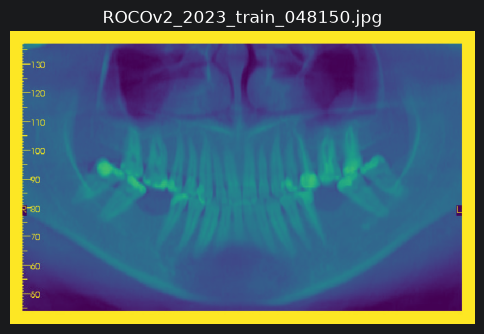

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample = random.choice(train_images)

img = Image.open(sample)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(sample.name)
plt.show()

In [15]:
widths = []
heights = []

for img_path in train_images[:1000]:  # First 1000 images
    img = Image.open(img_path)
    widths.append(img.width)
    heights.append(img.height)

print("Average Width :", sum(widths)/len(widths))
print("Average Height:", sum(heights)/len(heights))

Average Width : 640.293
Average Height: 592.718


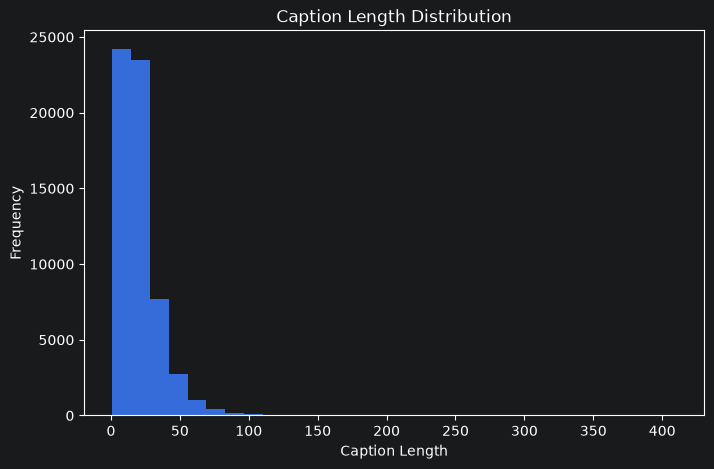

In [16]:
plt.figure(figsize=(8,5))
plt.hist(train_df["caption_length"], bins=30)
plt.xlabel("Caption Length")
plt.ylabel("Frequency")
plt.title("Caption Length Distribution")
plt.show()

In [20]:
bad = []

for img in train_images:
    try:
        Image.open(img).verify()
    except:
        bad.append(img)

print(len(bad))

0
